In [13]:
from google.colab import files
files = files.upload()

Saving flight_components_condition_expanded (1).xlsx to flight_components_condition_expanded (1) (2).xlsx


  Component ID Component Type                 Model Serial Number  \
0    COMP-0001            APU  Auxiliary Power Unit     SN-688508   
1    COMP-0002   Landing Gear            Brake Unit     SN-498382   
2    COMP-0003         Engine               GEnx-1B     SN-838797   
3    COMP-0004         Engine              CFM56-7B     SN-835911   
4    COMP-0005            APU  Auxiliary Power Unit     SN-158655   

        Manufacturer Aircraft ID Install Date  Flight Hours  Cycles  \
0          Honeywell      AC-100   2025-01-29        6912.0    4638   
1          Honeywell      AC-108   2024-03-05        5550.0    2822   
2  Collins Aerospace      AC-105   2024-09-10        6649.8    5292   
3             Safran      AC-103   2025-03-02        7270.2    5576   
4              Eaton      AC-109   2024-10-12        4319.9    2011   

   Wear Level (%) Condition Status Last Inspection Date Next Inspection Due  \
0            52.7         Marginal           2026-05-14          2027-05-14   


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6931 - loss: 0.8260 - val_accuracy: 0.7950 - val_loss: 0.4936
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3890 - val_accuracy: 0.9225 - val_loss: 0.2999
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9375 - loss: 0.2735 - val_accuracy: 0.9350 - val_loss: 0.2386
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9388 - loss: 0.2231 - val_accuracy: 0.9375 - val_loss: 0.2029
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1793 - val_accuracy: 0.9450 - val_loss: 0.1737
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.1489 - val_accuracy: 0.9425 - val_loss: 0.1503
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9594 - loss: 0.1264 - val_accuracy: 0.9575 - val_loss: 0.1357
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.1109 - val_accuracy: 0.9500 - val_loss: 0.1305
Epo

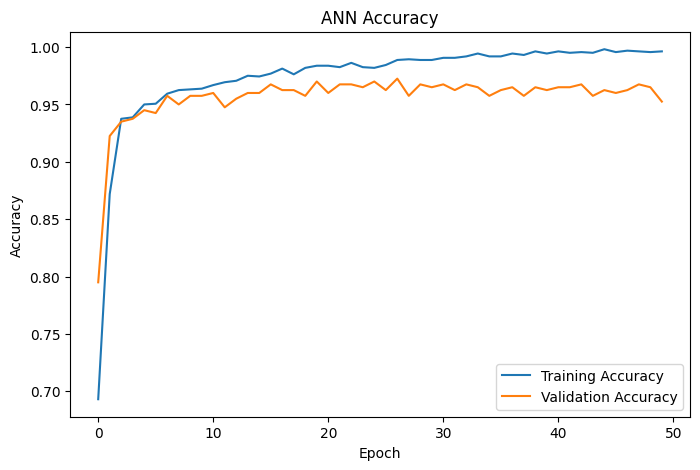

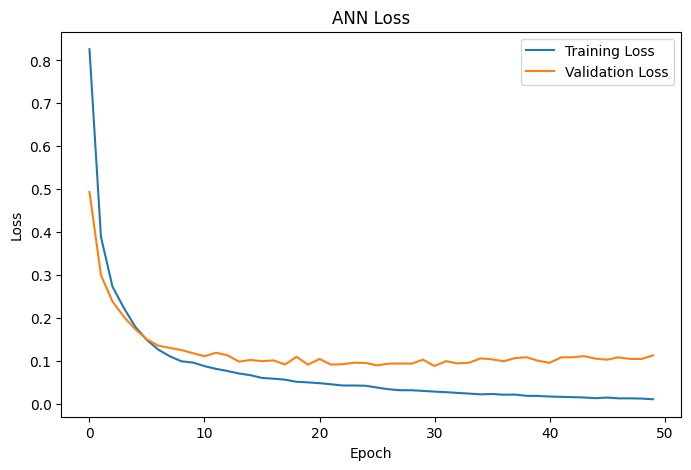


Model Saved Successfully!


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
df = pd.read_excel("flight_components_condition_expanded (1).xlsx")
print(df.head())
print("\nDataset Shape:", df.shape)
df.ffill(inplace=True)
date_columns = ["Install Date",
                "Last Inspection Date",
                "Next Inspection Due"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])
    df[col] = df[col].map(pd.Timestamp.toordinal)
encoders = {}

categorical = [
    "Component ID",
    "Component Type",
    "Model",
    "Serial Number",
    "Manufacturer",
    "Aircraft ID",
    "Condition Status"
]

for col in categorical:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

X = df.drop("Condition Status", axis=1)

y = df["Condition Status"]
scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

num_classes = len(np.unique(y))
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("Test Accuracy :", round(accuracy*100,2),"%")
print("Test Loss     :", loss)
print("==============================")
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)
acc = accuracy_score(y_test, pred_classes)

print("\nAccuracy Score:", round(acc*100,2),"%")
cm = confusion_matrix(y_test, pred_classes)

print("\nConfusion Matrix")
print(cm)
print("\nClassification Report")
print(classification_report(y_test, pred_classes))
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy")

plt.legend()

plt.show()
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Loss")

plt.legend()

plt.show()
model.save("AircraftMaintenanceModel.keras")

print("\nModel Saved Successfully!")

## Model Accuracy Summary

In [15]:
print(f"Final Test Accuracy: {round(accuracy * 100, 2)}%")

Final Test Accuracy: 94.2%


In [17]:
num_classes = len(np.unique(y))
num_classes

4